In [3]:
import pandas as pd
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path().resolve().parents[0]))

from src.data_loader import load_train_data

train = load_train_data()

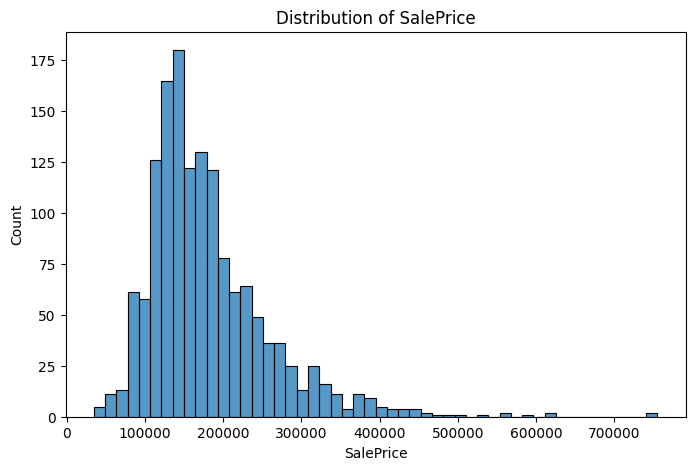

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"], bins=50)
plt.title("Distribution of SalePrice")
plt.show()

The SalePrice distribution is heavily right-skewed.
This indicates that most houses are concentrated in lower price ranges,
with fewer high-price properties.

In [5]:
train["SalePrice_log"] = np.log1p(train["SalePrice"])

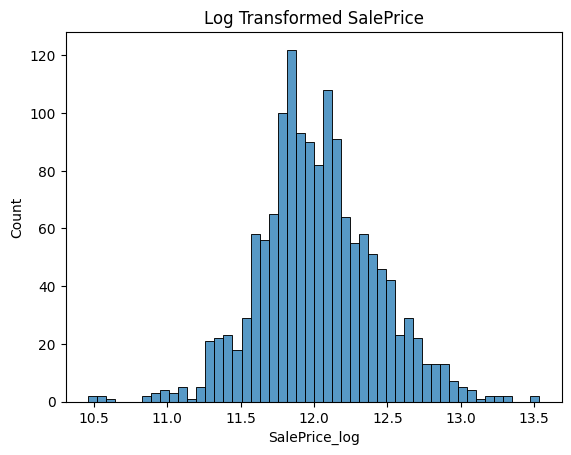

In [6]:
sns.histplot(train["SalePrice_log"], bins=50)
plt.title("Log Transformed SalePrice")
plt.show()

Log transformation reduces skewness and produces a more normal distribution.
This is beneficial for many machine learning models.

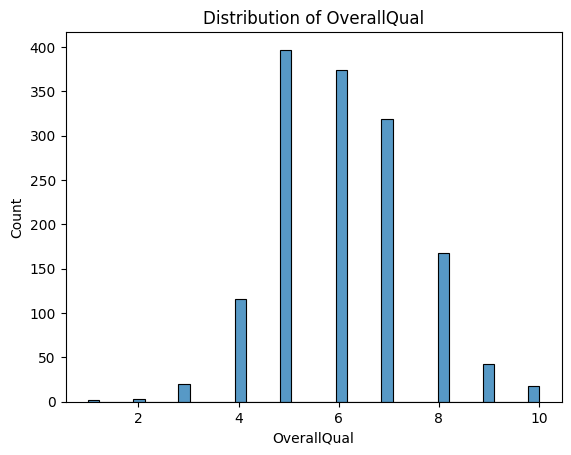

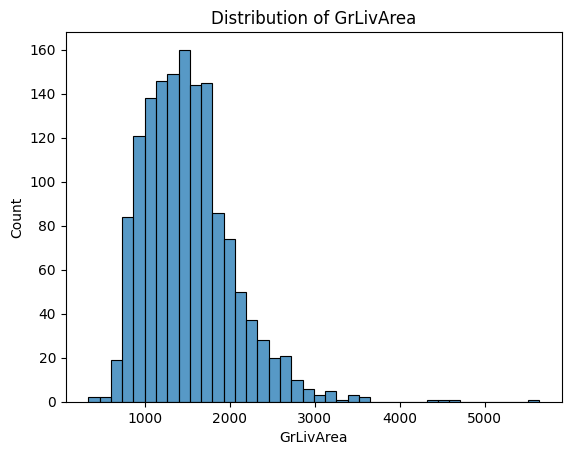

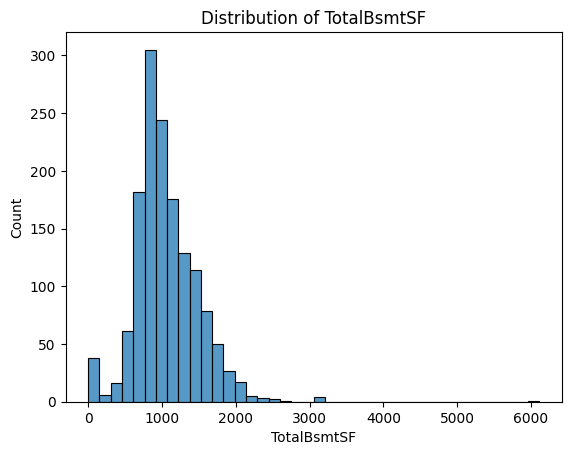

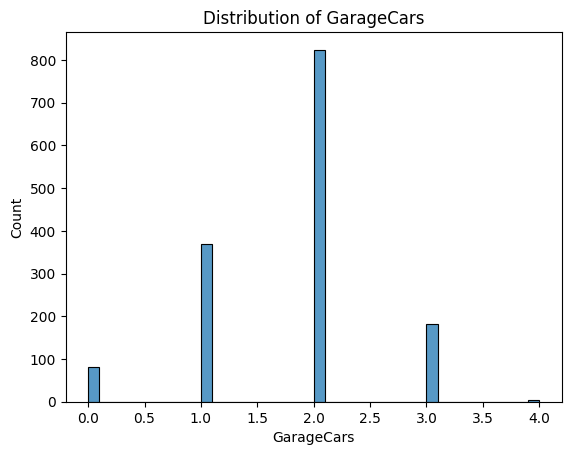

In [7]:
features = ["OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars"]

for feature in features:
    
    plt.figure()
    sns.histplot(train[feature], bins=40)
    plt.title(f"Distribution of {feature}")
    plt.show()

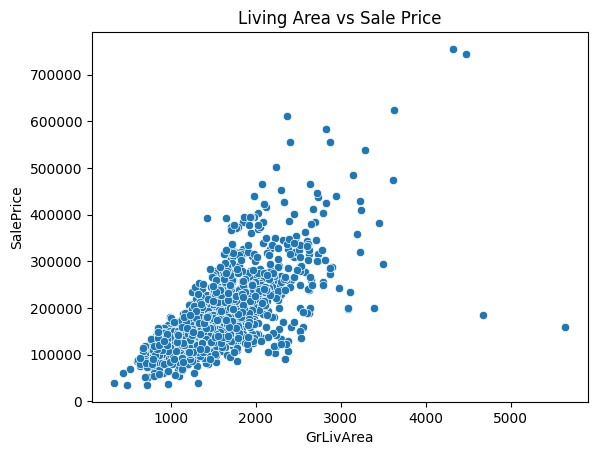

In [8]:
plt.figure()
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.title("Living Area vs Sale Price")
plt.show()

Larger living areas tend to correspond to higher sale prices.
However, some extreme outliers are visible.

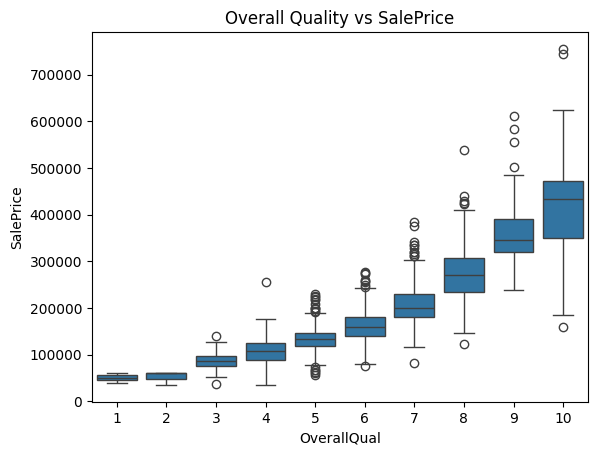

In [9]:
sns.boxplot(x=train["OverallQual"], y=train["SalePrice"])
plt.title("Overall Quality vs SalePrice")
plt.show()

Higher quality houses have significantly higher sale prices.
OverallQual appears to be one of the strongest predictors.

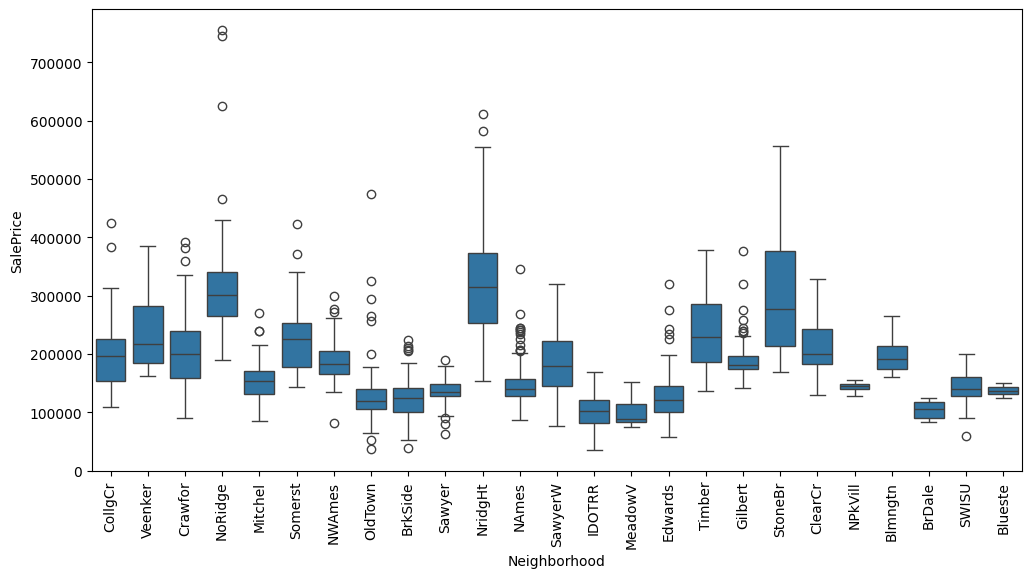

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Neighborhood", y="SalePrice", data=train)
plt.xticks(rotation=90)
plt.show()

Sale prices vary significantly across neighborhoods,
indicating strong geographic influence on house prices.

In [11]:
corr = train.corr(numeric_only=True)

corr["SalePrice"].sort_values(ascending=False).head(10)

SalePrice        1.000000
SalePrice_log    0.948374
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
Name: SalePrice, dtype: float64

Key findings:

- SalePrice is highly right-skewed
- Log transformation improves distribution
- OverallQual strongly impacts price
- Living area is positively correlated with price
- Neighborhood plays a significant role in house value